In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')

In [3]:
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [4]:
airbnb.dtypes

listing_id              int64
name                      str
host_id                 int64
host_name                 str
neighbourhood_full        str
coordinates               str
room_type                 str
price                     str
number_of_reviews       int64
last_review               str
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added             str
dtype: object

In [5]:
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  str    
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  str    
 4   neighbourhood_full  10019 non-null  str    
 5   coordinates         10019 non-null  str    
 6   room_type           10019 non-null  str    
 7   price               9781 non-null   str    
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   str    
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  str    
dtypes: float64(4), 

In [6]:
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

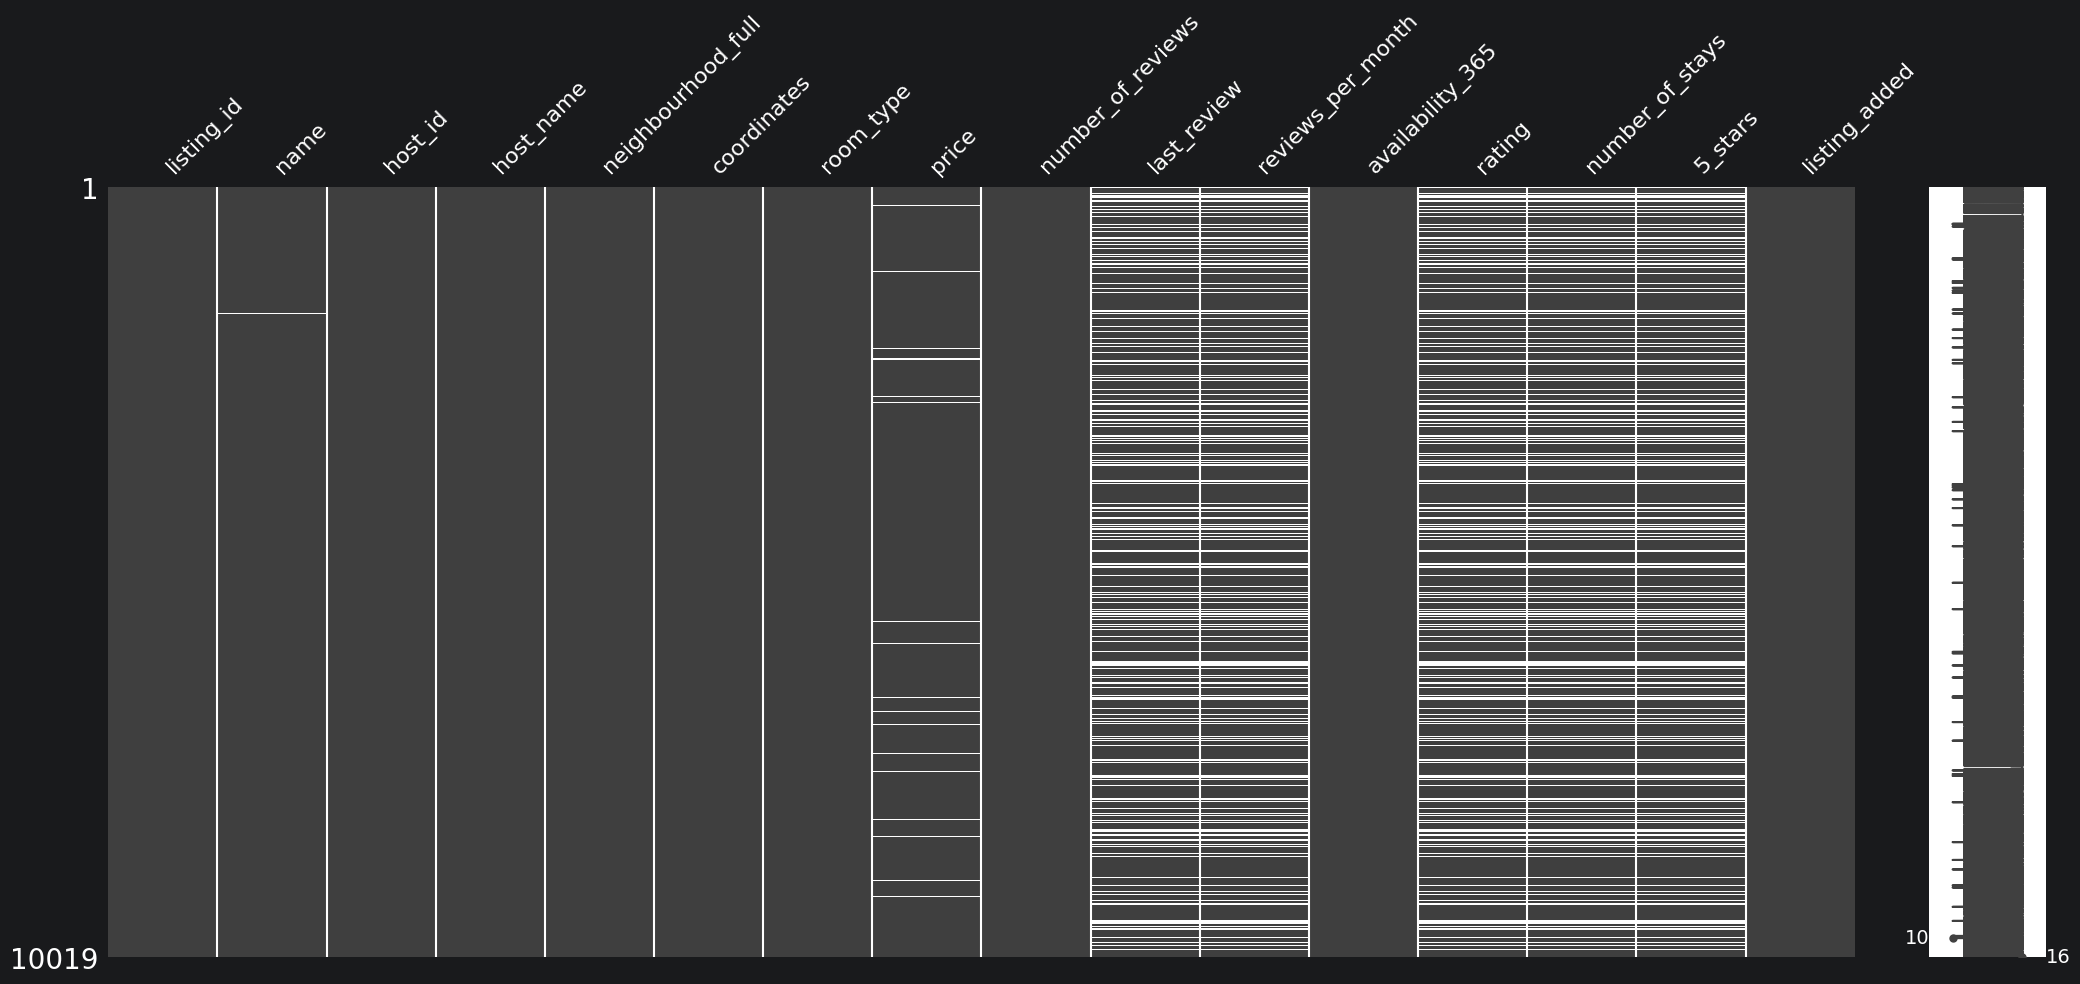

In [7]:
msno.matrix(airbnb)
plt.show()

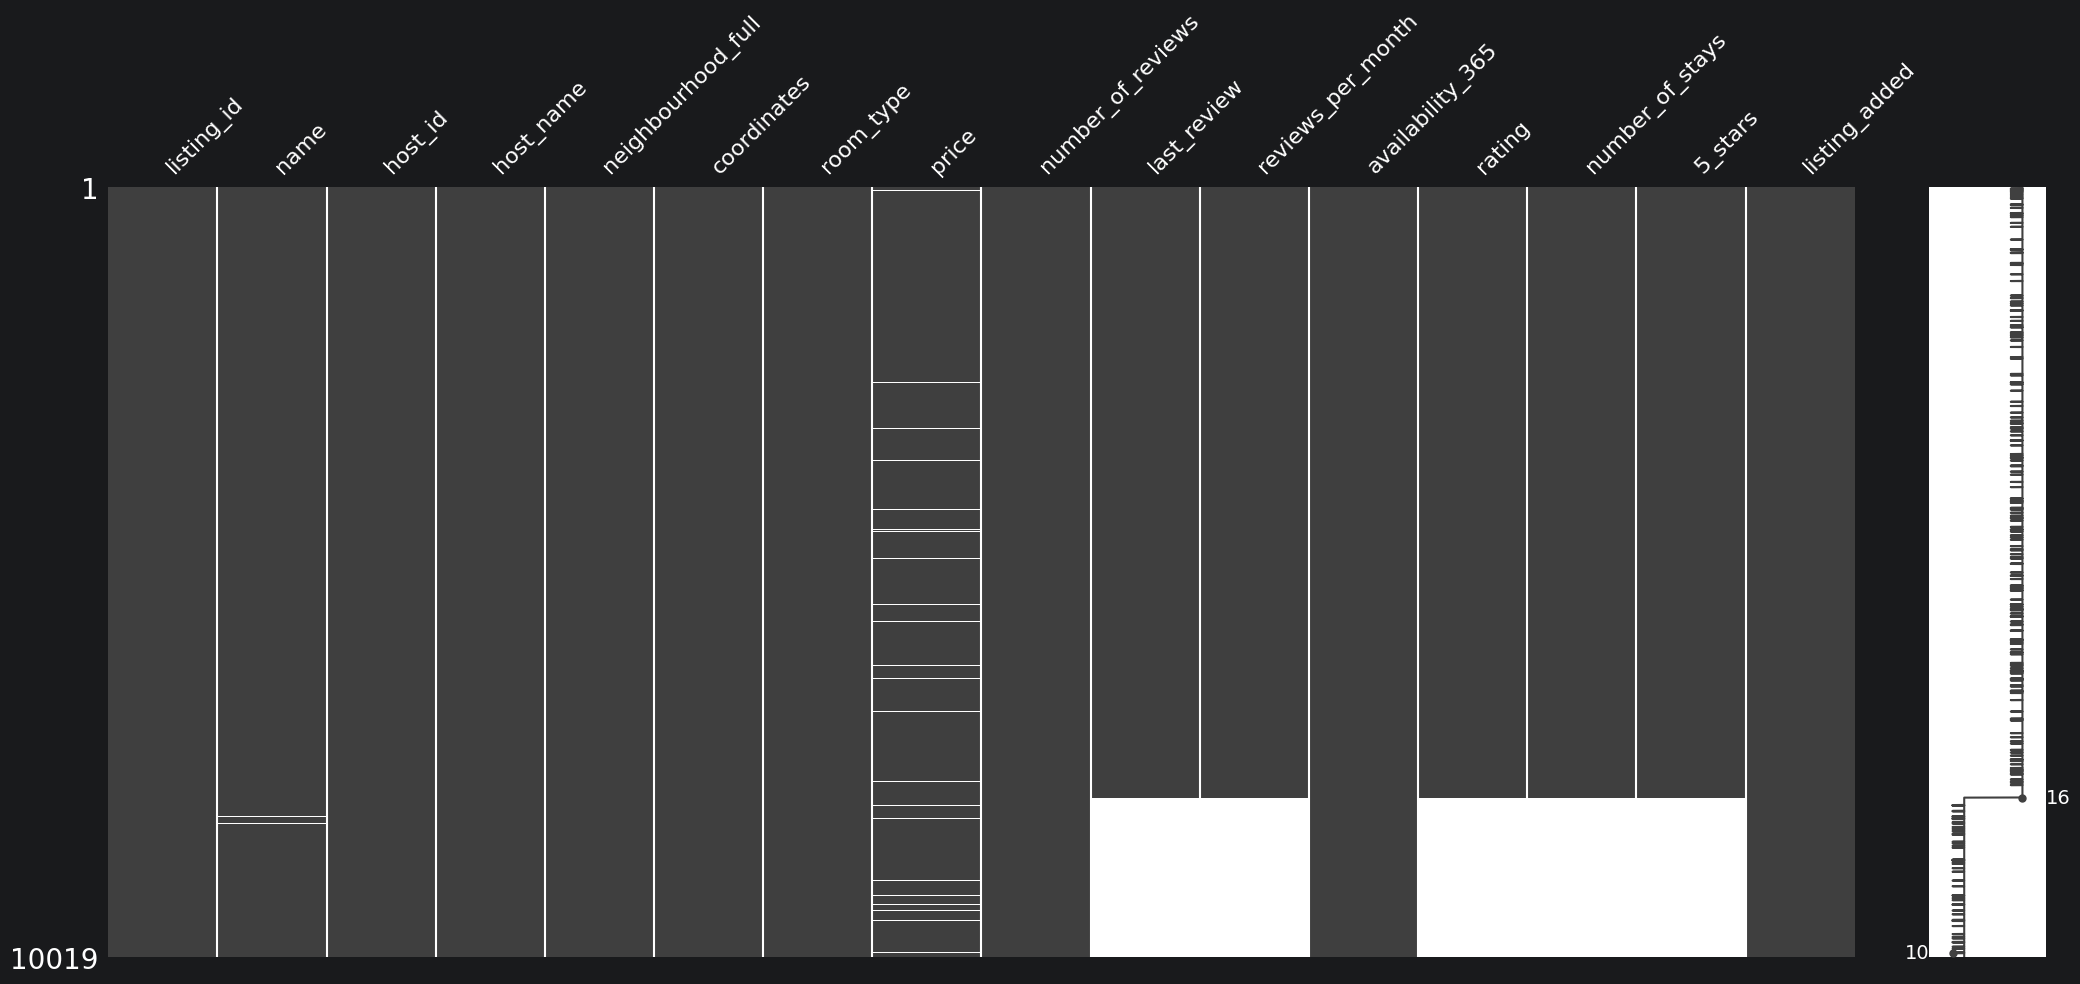

In [8]:
msno.matrix(airbnb.sort_values(by = 'rating'))
plt.show()

<Axes: >

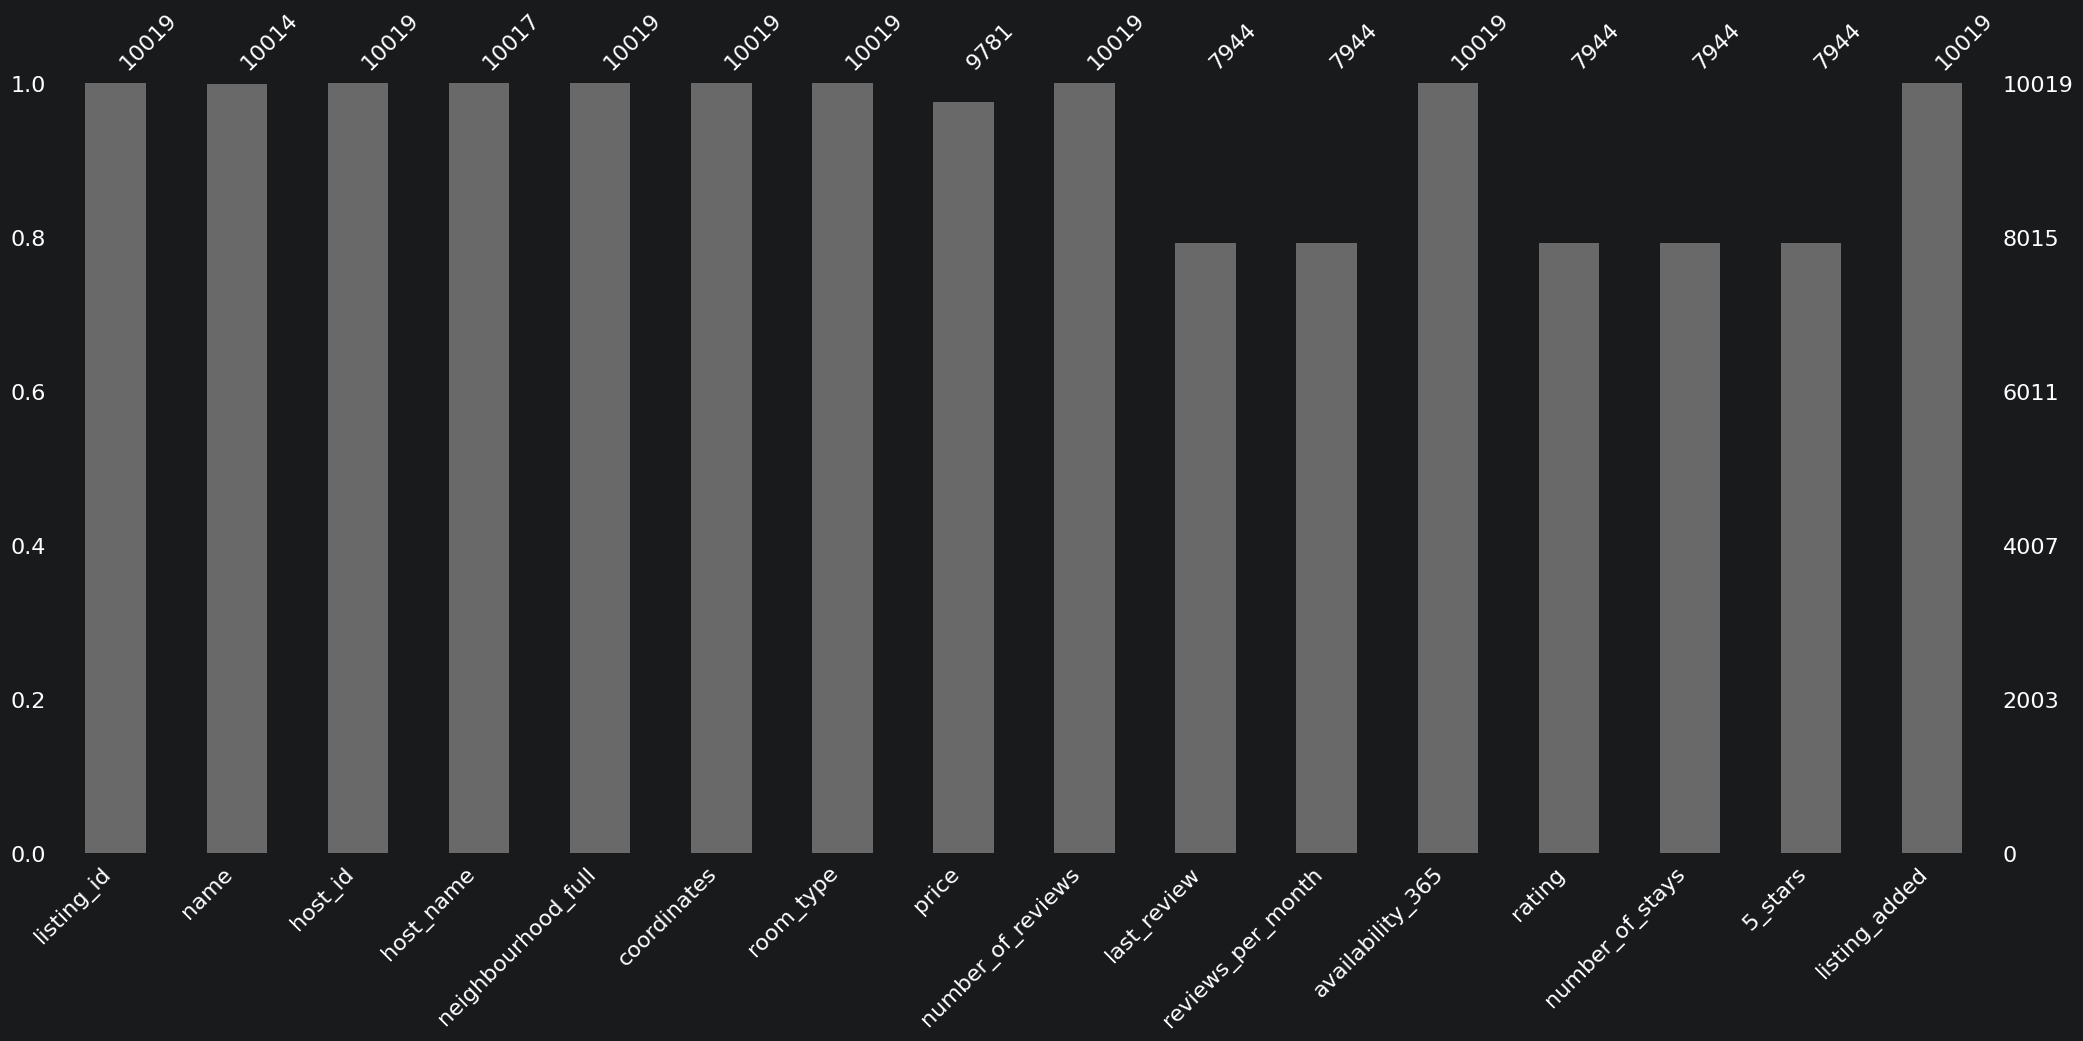

In [9]:
msno.bar(airbnb)

<Axes: >

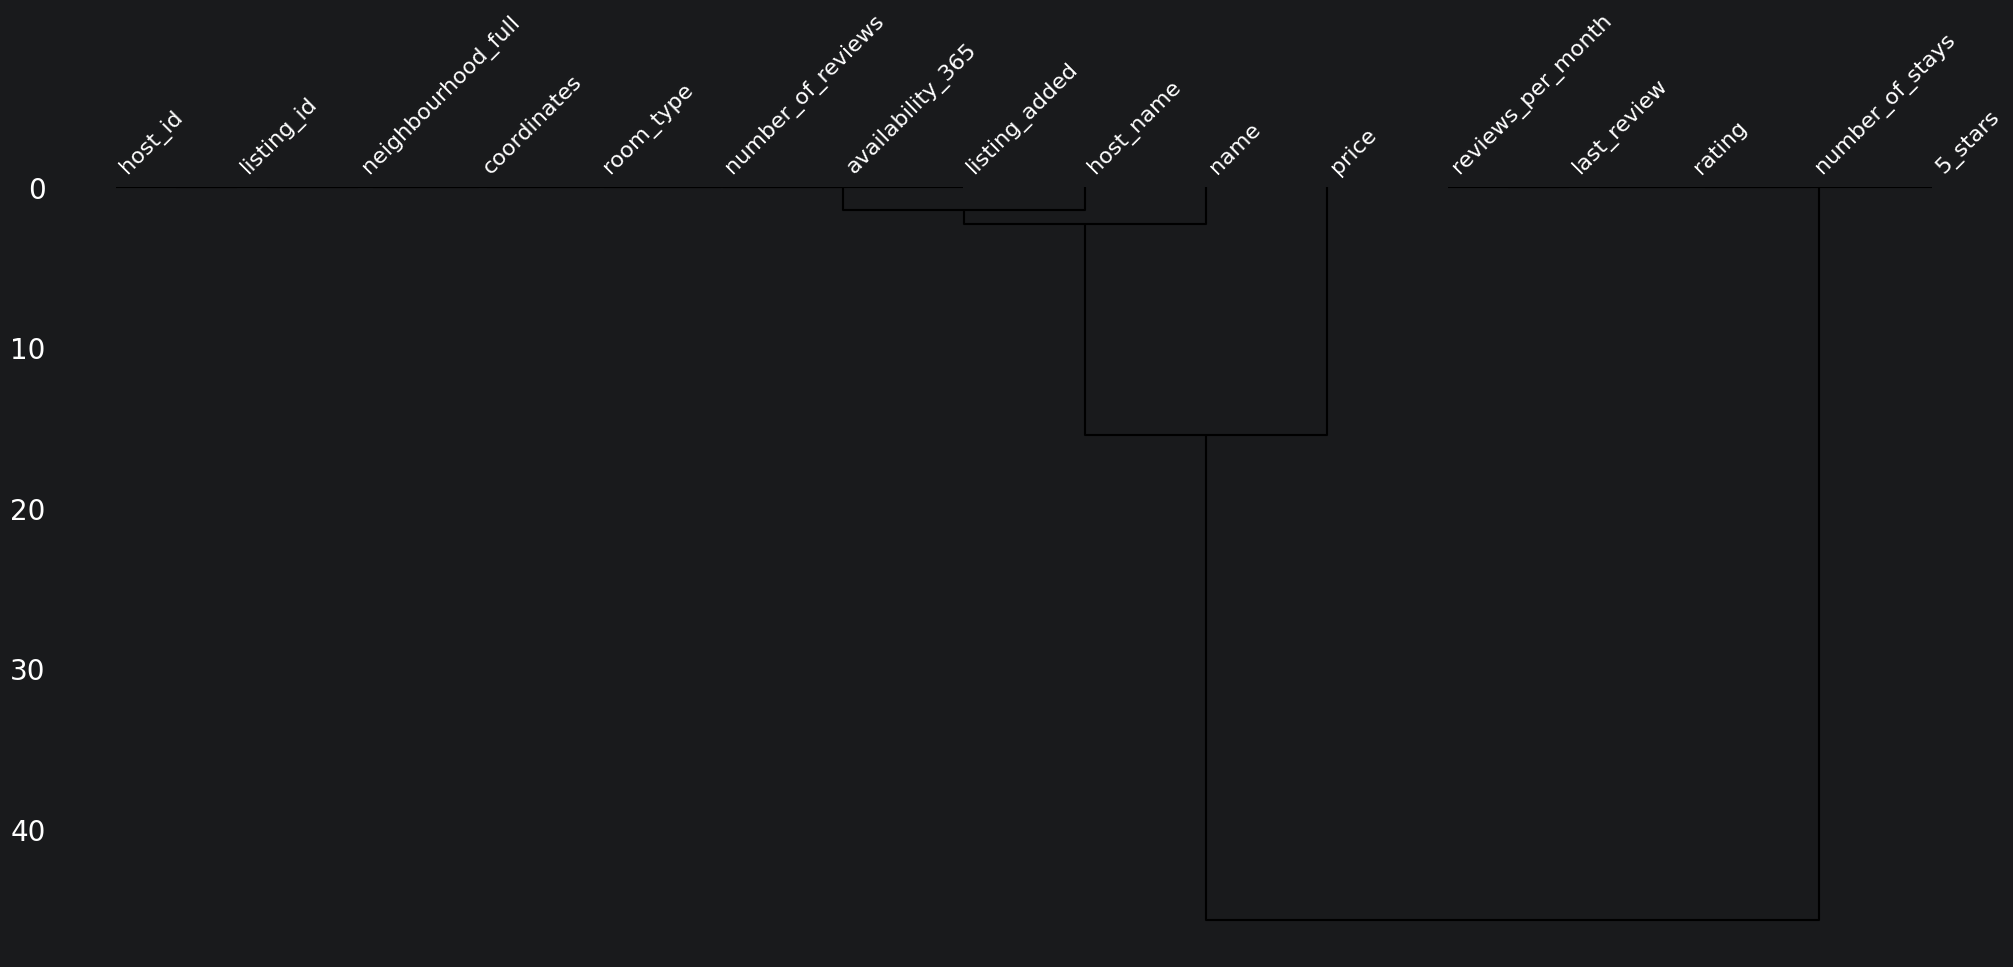

In [10]:
msno.dendrogram(airbnb)

# PRICE

In [11]:
airbnb['price'] = airbnb['price'].str.strip("$")
airbnb['price'].head()

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: str

In [12]:
airbnb['price'] = airbnb['price'].astype('float')
airbnb['price'].head()

0     45.0
1    135.0
2    150.0
3     86.0
4    160.0
Name: price, dtype: float64

In [18]:
srednie_ceny = airbnb.groupby('room_type')['price'].transform('mean').round(2)
airbnb['price'] = airbnb['price'].fillna(srednie_ceny)

# COORDINATES

In [23]:
airbnb['coordinates'].head()

0    (40.63222, -73.93398)
1    (40.78761, -73.96862)
2     (40.7007, -73.99517)
3    (40.79169, -73.97498)
4    (40.71884, -73.98354)
Name: coordinates, dtype: str

In [25]:
airbnb[['coordinates_x', 'coordinates_y']] = airbnb['coordinates'].str.strip('()').str.split(', ', expand=True)
airbnb['coordinates_x'] = airbnb['coordinates_x'].astype('float')
airbnb['coordinates_y'] = airbnb['coordinates_y'].astype('float')

In [29]:
airbnb['coordinates_x'].head()

0    40.63222
1    40.78761
2    40.70070
3    40.79169
4    40.71884
Name: coordinates_x, dtype: float64

In [31]:
airbnb['coordinates_y'].head()

0   -73.93398
1   -73.96862
2   -73.99517
3   -73.97498
4   -73.98354
Name: coordinates_y, dtype: float64

<Axes: >

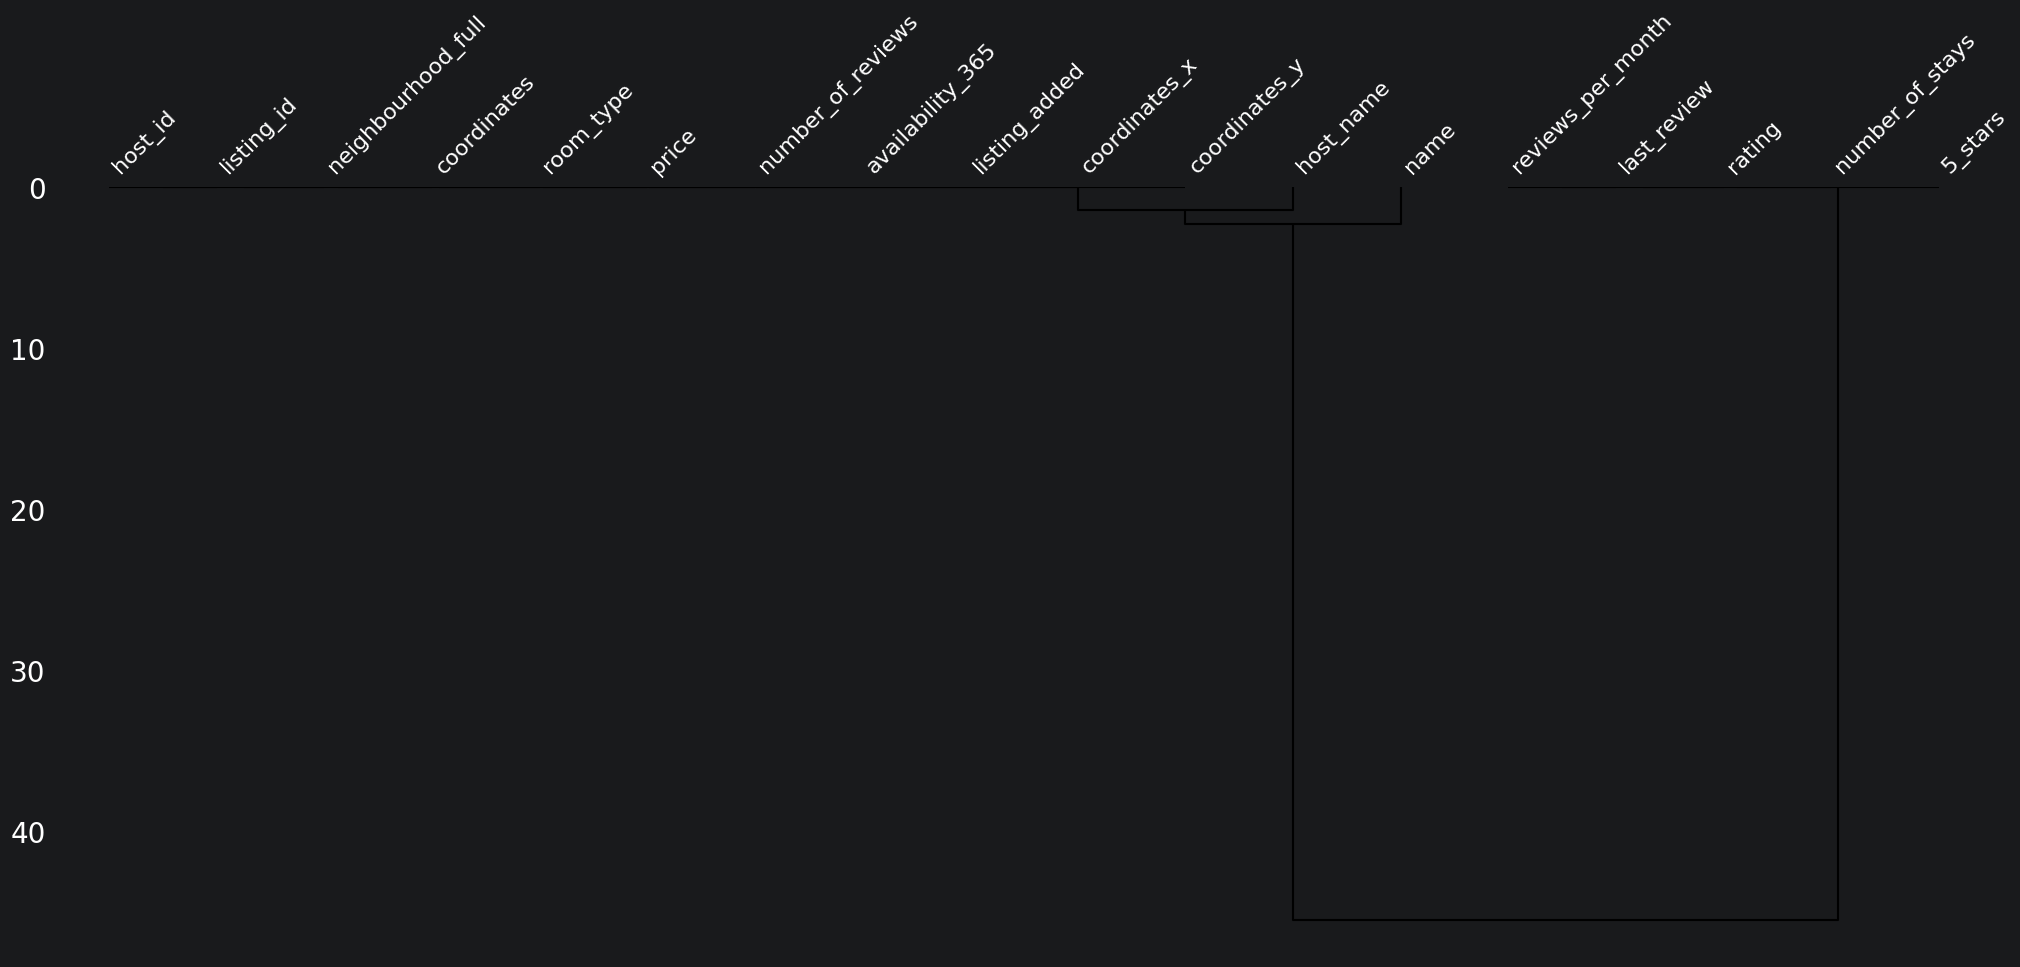